# Part 1f: Batch Normalization
**Author:** Kalhar Mayurbhai Patel (019140511)

Batch Normalization normalizes layer inputs to zero mean and unit variance within each mini-batch.
Benefits: faster convergence, allows higher learning rates, mild regularization effect.

In [1]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X, y = make_classification(n_samples=3000, n_features=30, n_informative=15, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## TensorFlow: With vs Without BatchNorm

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


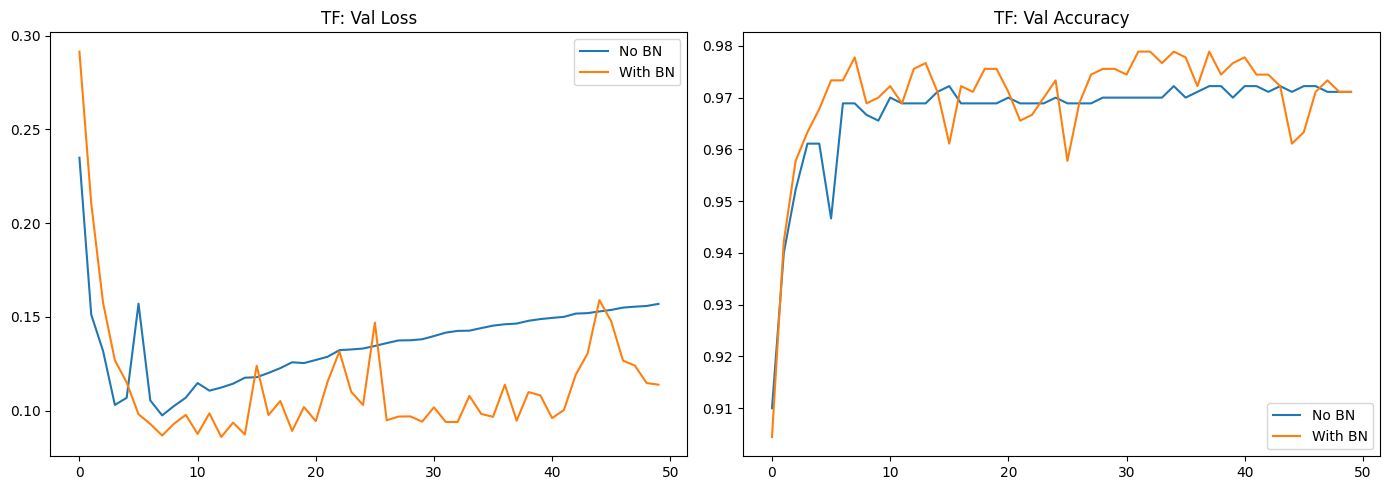

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, Sequential

# Without BN
m_no_bn = Sequential([
    layers.Dense(256, activation='relu', input_shape=(30,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
m_no_bn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
h1 = m_no_bn.fit(X_train, y_train, epochs=50, batch_size=64,
                  validation_data=(X_test, y_test), verbose=0)

# With BN (applied BEFORE activation for best results)
m_bn = Sequential([
    layers.Dense(256, input_shape=(30,)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dense(128),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dense(64),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dense(1, activation='sigmoid')
])
m_bn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
h2 = m_bn.fit(X_train, y_train, epochs=50, batch_size=64,
              validation_data=(X_test, y_test), verbose=0)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(h1.history['val_loss'], label='No BN')
ax[0].plot(h2.history['val_loss'], label='With BN')
ax[0].set_title('TF: Val Loss'); ax[0].legend()
ax[1].plot(h1.history['val_accuracy'], label='No BN')
ax[1].plot(h2.history['val_accuracy'], label='With BN')
ax[1].set_title('TF: Val Accuracy'); ax[1].legend()
plt.tight_layout(); plt.show()

## PyTorch: Batch Normalization

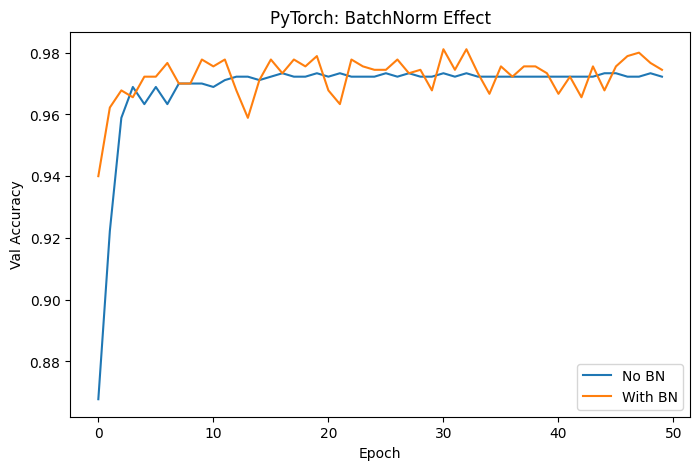

In [3]:
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dl = DataLoader(TensorDataset(torch.FloatTensor(X_train).to(device),
    torch.FloatTensor(y_train).unsqueeze(1).to(device)), batch_size=64, shuffle=True)
X_te = torch.FloatTensor(X_test).to(device)
y_te = torch.FloatTensor(y_test).unsqueeze(1).to(device)

class NoBN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(30,256), nn.ReLU(), nn.Linear(256,128),
                                 nn.ReLU(), nn.Linear(128,64), nn.ReLU(), nn.Linear(64,1), nn.Sigmoid())
    def forward(self, x): return self.net(x)

class WithBN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(30,256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256,128), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Linear(128,64), nn.BatchNorm1d(64), nn.ReLU(),
            nn.Linear(64,1), nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

def train_model(model, epochs=50):
    opt = torch.optim.Adam(model.parameters()); crit = nn.BCELoss(); accs = []
    for ep in range(epochs):
        model.train()
        for xb, yb in dl:
            opt.zero_grad(); crit(model(xb), yb).backward(); opt.step()
        model.eval()
        with torch.no_grad():
            accs.append(((model(X_te)>0.5).float()==y_te).float().mean().item())
    return accs

torch.manual_seed(42); a1 = train_model(NoBN().to(device))
torch.manual_seed(42); a2 = train_model(WithBN().to(device))

plt.figure(figsize=(8, 5))
plt.plot(a1, label='No BN'); plt.plot(a2, label='With BN')
plt.title('PyTorch: BatchNorm Effect'); plt.xlabel('Epoch')
plt.ylabel('Val Accuracy'); plt.legend(); plt.show()

## Summary
- BatchNorm normalizes each mini-batch to μ=0, σ=1, then applies learnable scale (γ) and shift (β)
- Placed **before** activation for best results (original paper recommendation)
- Enables higher learning rates → faster training
- Acts as mild regularizer (noise from mini-batch statistics)
- At inference, uses running averages instead of batch statistics